## E1b - Training Your Classifier
Author: George Gorospe, george.gorospe@nmaia.net\
Last Update: July 22, 2026

### About: This notebook builds a training dataset by pulling class folders in from wherever they already exist -- data you just collected in E1a, or any class folder from earlier in the week -- then trains a classifier on however many classes you've assembled.
### Same `preview_dataset` / `prepare_dataloaders` / `build_model` / `train_model` pattern as every training notebook this week. None of that changes based on how many classes you use.

<span style="color: orange; font-size: 55px; font-style: italic;">ACTIVITY E1b.1: Name Your Dataset</span>

In [1]:
##### ----- RUN THIS CELL WITHOUT CHANGING IT ----- #####
# STEP 1. Import required libraries

import os
from ipyfilechooser import FileChooser

from capture_utils import ensure_directory, copy_class_directory
from train_utils import preview_dataset, prepare_dataloaders, build_model, train_model

/home/explorer/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### Name the dataset you're building for today's challenge.

In [2]:
##### ----- FEEL FREE TO CHANGE THIS VALUE ----- #####
dataset_name = "challenge_dataset"

In [3]:
##### ----- RUN THIS CELL WITHOUT CHANGING IT ----- #####

data_dir = os.path.join(os.path.expanduser("~"), "Datasets", dataset_name)
ensure_directory(data_dir)
print(f"Dataset directory ready: {data_dir}")

Dataset directory ready: /home/explorer/Datasets/challenge_dataset


<span style="color: orange; font-size: 55px; font-style: italic;">ACTIVITY E1b.2: Add Classes</span>

### Do this part multiple times! Add one class at a time. For each class you want in your dataset:
1. Run the file chooser cell below, navigate **into** the folder of images for that class (e.g. a `single/` folder from an E1a dataset, or a `red/` folder from earlier this week), and click **Select**.
2. Run the copy cell. The class is named after the folder you picked -- select `single/` and you get a class called `single`.
3. **Repeat both cells** for every other class you need.

### Your E1a datasets count as "other datasets" here too -- anything you collected this morning is fair game to pull in.
### Because the class name now comes from the folder name, the folder names you chose in E1a become your class names here.

In [4]:
##### ----- RUN THIS CELL WITHOUT CHANGING IT ----- #####
# Browse to a CLASS FOLDER (not a file) you want to add.

source_chooser = FileChooser(os.path.join(os.path.expanduser("~"), "Datasets"))
source_chooser.show_only_dirs = True
display(source_chooser)

FileChooser(path='/home/explorer/Datasets', filename='', title='', show_hidden=False, select_desc='Select', ch…

In [6]:
##### ----- RUN THIS CELL WITHOUT CHANGING IT ----- #####

# The class name comes from the folder you picked above: select
# .../my_challenge_dataset/single and this class is called 'single'.
if source_chooser.selected is None:
    raise ValueError(
        "No folder selected yet. Use the file chooser above to open a class "
        "folder, click Select, then run this cell again."
    )

class_name = os.path.basename(os.path.normpath(source_chooser.selected))

dest_directory = os.path.join(data_dir, class_name)
copied = copy_class_directory(source_chooser.selected, dest_directory)

if copied == 0:
    # os.rmdir only ever removes an EMPTY directory, so this cannot delete
    # images -- it just clears away the empty class folder that would
    # otherwise make prepare_dataloaders fail further down.
    try:
        os.rmdir(dest_directory)
    except OSError:
        pass
    print(f"No images found in '{class_name}'. Did you select the dataset "
          f"folder instead of a class folder inside it? Choose the folder "
          f"that actually holds the .jpg files.")
else:
    print(f"Copied {copied} images into '{class_name}'.")

Copied 705 images into 'blue'.


### Repeat the two cells above for each additional class. When you've added everything you need, continue below.

<span style="color: orange; font-size: 55px; font-style: italic;">ACTIVITY E1b.3: Preview and Train</span>

Dataset preview:
  blue: 705 images
  free: 1003 images
  wall: 238 images


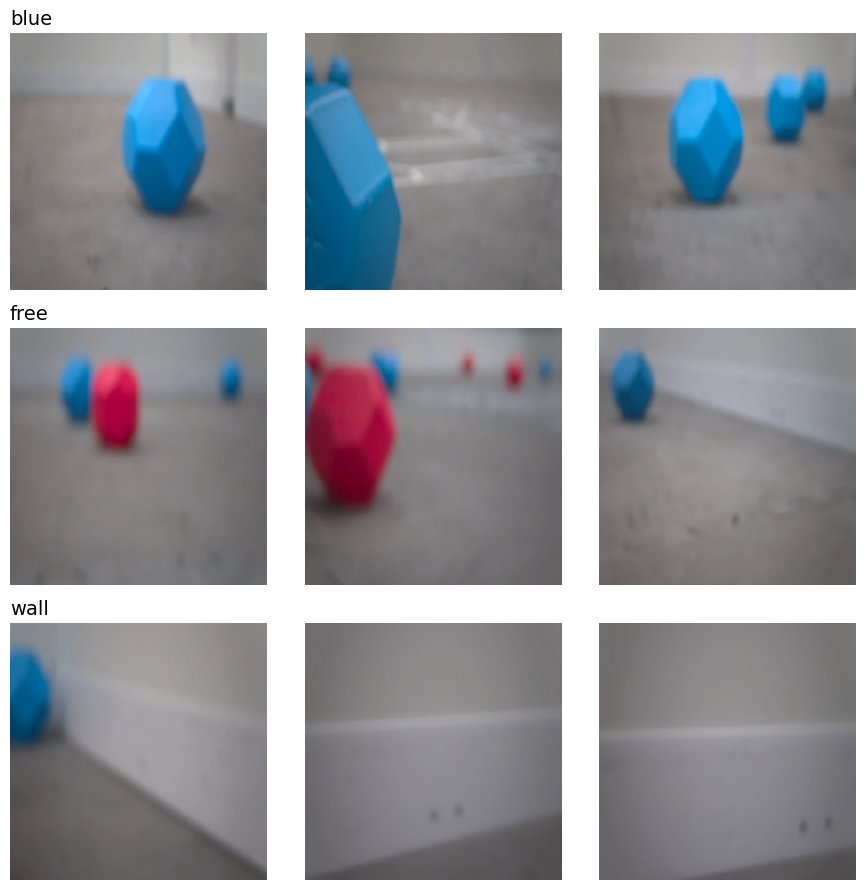

In [7]:
##### ----- RUN THIS CELL WITHOUT CHANGING IT ----- #####
preview_dataset(data_dir)

### Check your classes and counts above -- at least 200 images per class, with good variety, before training. It's much cheaper to collect more now than to retrain later.

In [8]:
##### ----- FEEL FREE TO CHANGE THESE VALUES ----- #####
model_name = "challenge_classifier_v1"
epochs = 2
learning_rate = 0.001
momentum = 0.9
batch_size = 8  # keep this at 8 or 16 -- see B3a notes on Jetson memory limits

In [9]:
##### ----- RUN THIS CELL WITHOUT CHANGING IT ----- #####
train_loader, test_loader, class_names = prepare_dataloaders(
    data_dir,
    batch_size=batch_size,
    test_fraction=0.2
)

Found 1946 images across 3 classes:
  blue: 705 images
  free: 1003 images
  wall: 238 images


In [10]:
##### ----- RUN THIS CELL WITHOUT CHANGING IT ----- #####
model, device = build_model(num_classes=len(class_names))

Epoch 1/2 -- train loss: 0.3214, test accuracy: 93.1%
Epoch 2/2 -- train loss: 0.1305, test accuracy: 94.9%
Training complete!
Training plot saved to /home/explorer/Models/best_model_challenge_classifier_v1.png


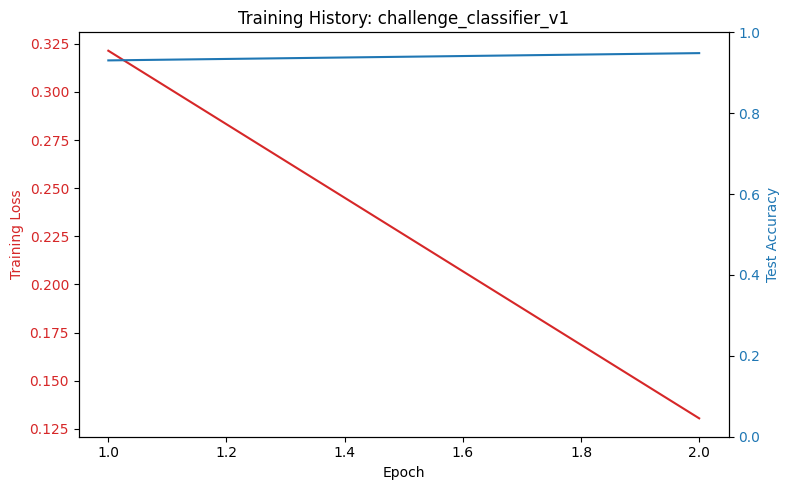

TRAINING SUMMARY -- copy this into your notebook!
Model name:          challenge_classifier_v1
Classes:             blue, free, wall
Training images:     1557
Test images:         389
Epochs:              2
Learning rate:       0.001
Momentum:            0.9
Batch size:          8
Training duration:   1m 16s
Best epoch:          2
Best test accuracy:  94.9%
Model saved to:      /home/explorer/Models/best_model_challenge_classifier_v1.pth


In [11]:
##### ----- RUN THIS CELL WITHOUT CHANGING IT ----- #####
history, training_record = train_model(
    model,
    train_loader,
    test_loader,
    device,
    class_names,
    data_dir,
    model_name,
    epochs,
    learning_rate,
    momentum,
)

## Your model is trained and saved. Move on to E1c to build the program that uses it -- yours, or a second model, if your flowchart uses two.